In [1]:
import struct
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# ========== Load Dataset ==========
def load_images(filename):
    with open(filename, 'rb') as f:
        _, num, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape((num, rows * cols))
        return data.astype(np.float32) / 255.0


def load_labels(filename):
    with open(filename, 'rb') as f:
        _, num = struct.unpack(">II", f.read(8))
        return np.frombuffer(f.read(), dtype=np.uint8)

In [3]:
# ========== 1. Sigmoid Function ==========
def sigmoid(z):
    # TODO: Implement sigmoid function (optional)
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)


# TODO: Implement Backprop Autodiff
# ====== 3. Forward and Reverse Autodiff Trace ========
def trace_autodiff_example(x1, x2):
    w1, w2 = 0.5, -0.5 # Dummy weights for the trace example

    # Primal
    v1 = w1
    v2 = x1
    v3 = w2
    v4 = x2
    v5 = v1 * v2  # w1 * x1
    v6 = v3 * v4  # w2 * x2
    v7 = v5 + v6  # w1*x1 + w2*x2

    # Forward tangent
    dv1 = 1.0
    dv2 = 0.0
    dv3 = 0.0
    dv4 = 0.0
    dv5 = dv1 * v2 + v1 * dv2  # product rule
    dv6 = dv3 * v4 + v3 * dv4  # product rule
    dv7 = dv5 + dv6            # sum rule

    # Reverse adjoint
    # Seed value for the output node
    v7_bar = 1.0 
    
    # Adjoints for v5 and v6 (from v7 = v5 + v6)
    v5_bar = v7_bar * 1.0
    v6_bar = v7_bar * 1.0
    
    # Adjoints for v1, v2, v3, v4 (from v5 = v1*v2 and v6 = v3*v4)
    v1_bar = v5_bar * v2
    v2_bar = v5_bar * v1
    v3_bar = v6_bar * v4
    v4_bar = v6_bar * v3

    # Construct the trace table matching the required pandas format
    table = pd.DataFrame({
        'Variable': ['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7'],
        'Primal (v)': [v1, v2, v3, v4, v5, v6, v7],
        'Forward Tangent (ẋ)': [dv1, dv2, dv3, dv4, dv5, dv6, dv7],
        'Reverse Adjoint (v̄)': [v1_bar, v2_bar, v3_bar, v4_bar, v5_bar, v6_bar, v7_bar]
    })

    return table


# TODO: Implement SGD (use your codes last week), then use the backprop inside
# ========== 2. SGD: Algorithm 7.1 ==========
def your_sgd_logistic(X, y, eta, max_iters):
    N, d = X.shape
    w = np.zeros(d)
    trace = None

    for i in range(max_iters):
        # Forward pass
        z = np.dot(X, w)
        y_pred = sigmoid(z)
        
        # Gradient calculation via backpropagation [cite: 31]
        # For Binary Cross Entropy + Sigmoid, dL/dz = y_pred - y
        dz = y_pred - y
        dw = np.dot(X.T, dz) / N
        
        # Weight update
        w -= eta * dw

        # Capture autodiff trace on the first iteration using sample features
        if i == 0:
            # Using the first two features (after bias) of the first data point
            trace = trace_autodiff_example(X[0, 1], X[0, 2])
    return w, trace

In [4]:
# ==========Show Misclassified Samples ==========
def show_misclassified(X, y_true, y_pred, max_show=10):
    mis_idx = np.where(y_true != y_pred)[0][:max_show]
    if len(mis_idx) == 0:
        print("No misclassifications!")
        return
    plt.figure(figsize=(10, 2))
    for i, idx in enumerate(mis_idx):
        plt.subplot(1, len(mis_idx), i + 1)
        plt.imshow(X[idx, 1:].reshape(28, 28), cmap='gray')
        plt.axis('off')
        plt.title(f"T:{y_true[idx]}\nP:{y_pred[idx]}")
    plt.suptitle("Misclassified Samples")
    plt.show()



# ========== Plot Trace Graph ==========
def plot_autodiff_traces(trace_df):
    variables = trace_df['Variable']
    primal = trace_df['Primal (v)'].astype(float)
    forward = pd.to_numeric(trace_df['Forward Tangent (ẋ)'], errors='coerce')
    reverse = pd.to_numeric(trace_df['Reverse Adjoint (v̄)'], errors='coerce')


    fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)


    ax[0].bar(variables, primal, color='skyblue')
    ax[0].set_ylabel("Primal (v)")
    ax[0].set_title("Primal Values")


    ax[1].bar(variables, forward, color='lightgreen')
    ax[1].set_ylabel("Forward Tangent (ẋ)")
    ax[1].set_title("Forward-Mode Autodiff")


    ax[2].bar(variables, reverse, color='salmon')
    ax[2].set_ylabel("Reverse Adjoint (v̄)")
    ax[2].set_title("Reverse-Mode Autodiff")
    ax[2].set_xlabel("Variables")


    plt.tight_layout()
    plt.show()


Test Accuracy (is 3 or not): 0.9571


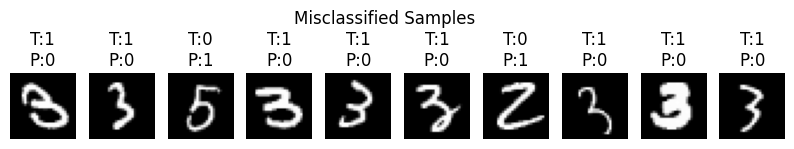


Autodiff Trace Table (sample features):
  Variable  Primal (v)  Forward Tangent (ẋ)  Reverse Adjoint (v̄)
0       v1         0.5                  1.0                   0.0
1       v2         0.0                  0.0                   0.5
2       v3        -0.5                  0.0                   0.0
3       v4         0.0                  0.0                  -0.5
4       v5         0.0                  0.0                   1.0
5       v6        -0.0                  0.0                   1.0
6       v7         0.0                  0.0                   1.0


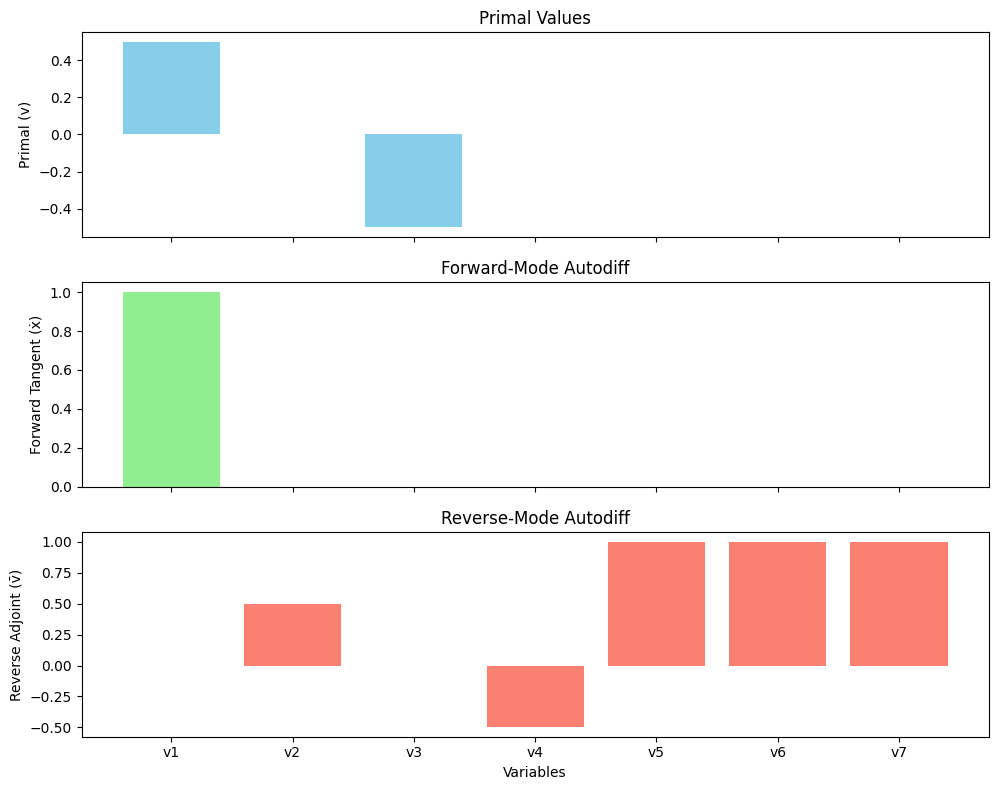

In [5]:
# ========== 3. Main ==========
def main():
    # === Load MNIST Data ===
    X_train = load_images("train-images.idx3-ubyte__")
    y_train = load_labels("train-labels.idx1-ubyte__")
    X_test = load_images("t10k-images.idx3-ubyte__")
    y_test = load_labels("t10k-labels.idx1-ubyte__")


    # === Binary Classification ===
    TARGET_DIGIT = 3 # TODO: Fill in (0 to 9) based on your student number
    y_train_bin = np.where(y_train == TARGET_DIGIT, 1, 0)
    y_test_bin = np.where(y_test == TARGET_DIGIT, 1, 0)


    # === Add Bias ===
    X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
    X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])


    # === Train ===
    w, autodiff_trace = your_sgd_logistic(X_train, y_train_bin, eta=0.1, max_iters=100)


    # === Predict ===
    pred_probs = sigmoid(np.dot(X_test, w))
    preds = (pred_probs >= 0.5).astype(int)


    # === Accuracy ===
    acc = np.mean(preds == y_test_bin)
    print(f"\nTest Accuracy (is {TARGET_DIGIT} or not): {acc:.4f}")


    # === Show Misclassifications ===
    show_misclassified(X_test, y_test_bin, preds)


    # === Visualize Autodiff Trace ===
    print("\nAutodiff Trace Table (sample features):")
    print(autodiff_trace)
    plot_autodiff_traces(autodiff_trace)


if __name__ == "__main__":
    main()